# Activations Functions and optimization - Assignment 2:

<a target="_blank" href="https://colab.research.google.com/github/sham-nlp/2026nlp-2-activation-functions/blob/main/02_activations_assignment_student.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

**Name:** `Eyad Al kadry`

**Date:** `7/3/2026`

---

## How To Complete The Tasks
1. Complete the code sections marked with `# YOUR CODE HERE` and `# YOUR CODE IN _`.
2. Run cells top-to-bottom in order.
3. Start with setup so all datasets/tensors are created once. (you don't have to change anything in the setup)
4. After each training section, read both the printed metrics and the plots.
5. Compare model behavior across tasks:
   linear model on linear data,
   linear model on nonlinear data,
   ReLU model on nonlinear data,
   sigmoid model for classification.

## Part 1: Setup

This section creates all datasets used later so training parts can focus only on modeling.

Data created in setup:
1. Linear regression data (`x`, `y`):
   To learn a straight-line relationship.
2. Nonlinear regression data (`x_nl`, `y_nl`):
   To show where a linear model underfits and ReLU helps.
3. Binary classification data (`x_cls`, `y_cls`):
   labels come from a noisy linear logit thresholded at 0.
   To train a sigmoid classifier and interpret probabilities.

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

np.random.seed(42)
torch.manual_seed(42)


def plot_loss(losses, title="Loss Curve", ylabel="Loss"):
    plt.figure(figsize=(7, 4))
    plt.plot(losses)
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.show()


def plot_fit(x, y, x_line, y_line, title):
    plt.figure(figsize=(7, 4))
    plt.scatter(x, y, s=16, alpha=0.5, label="data")
    plt.plot(x_line, y_line, color="black", linewidth=2, label="model prediction")
    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.show()


# Linear regression data
n_samples = 300
true_m = 3.2
true_b = -1.5
noise_std = 0.8

x = np.random.uniform(-5, 5, size=(n_samples, 1)).astype(np.float32)
noise = np.random.normal(0, noise_std, size=(n_samples, 1)).astype(np.float32)
y = true_m * x + true_b + noise

x = torch.tensor(x)
y = torch.tensor(y)

print(f"Linear data shape: {x.shape}")

Linear data shape: torch.Size([300, 1])


---

## Part 2: Build a Linear Model with Explicit Linear Activation


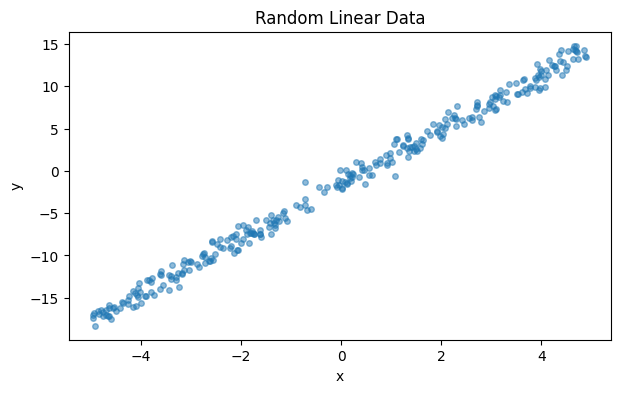

In [2]:
plt.figure(figsize=(7, 4))
plt.scatter(x, y, s=16, alpha=0.5)
plt.title("Random Linear Data")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [6]:
# Simpler linear model: use nn.Linear directly
model = torch.nn.Linear(1, 1)

# Use PyTorch built-in MSE loss
mse_loss = torch.nn.MSELoss()

In [7]:
# Reset model
model = torch.nn.Linear(1, 1)
optimizer = torch.optim.SGD(model.parameters(), lr=0.03)

epochs = 400
losses = []

for epoch in range(epochs):
    # Step 1: Forward pass
    y_pred = model(x)
    # Step 2: Compute loss
    loss = mse_loss(y_pred, y) # YOUR CODE IN _
    # Step 3: Zero previous gradients
    optimizer.zero_grad()
    # Step 4: Backward pass
    loss.backward()
    # Step 5: Update parameters
    optimizer.step()
    losses.append(loss.item())

    if (epoch + 1) % 100 == 0:
        print(
            f"Epoch {epoch + 1:>3}/{epochs} | MSE: {loss.item():.4f} | "
            f"weight: {model.weight.item():.3f}, bias: {model.bias.item():.3f}"
        )

print()
print("Training complete")
print(f"Final weight: {model.weight.item():.3f} (expected near true_m)")
print(f"Final bias: {model.bias.item():.3f} (expected near true_b)")

Epoch 100/400 | MSE: 0.6216 | weight: 3.221, bias: -1.509
Epoch 200/400 | MSE: 0.6216 | weight: 3.221, bias: -1.510
Epoch 300/400 | MSE: 0.6216 | weight: 3.221, bias: -1.510
Epoch 400/400 | MSE: 0.6216 | weight: 3.221, bias: -1.510

Training complete
Final weight: 3.221 (expected near true_m)
Final bias: -1.510 (expected near true_b)


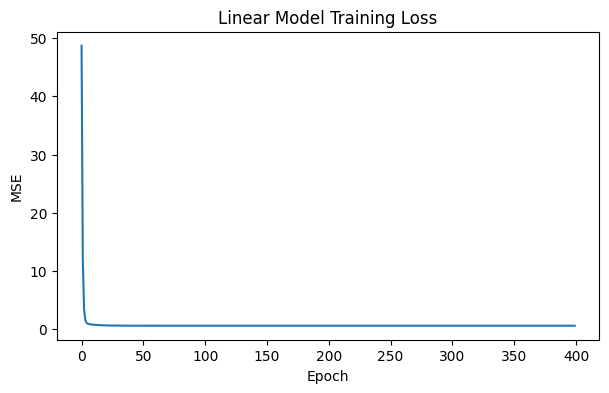

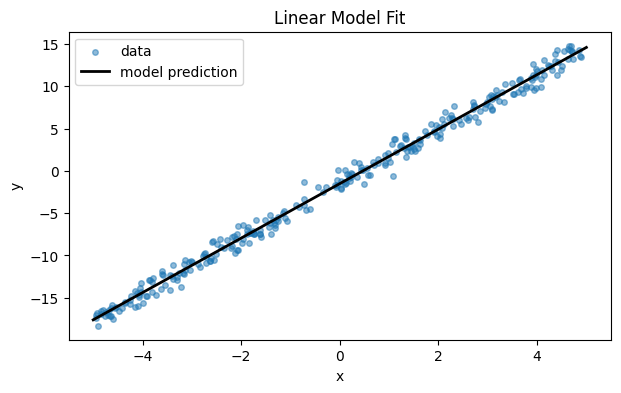

In [8]:
with torch.no_grad():
    x_line = torch.linspace(-5, 5, 200).reshape(-1, 1)
    y_line = model(x_line)

plot_loss(losses, title="Linear Model Training Loss", ylabel="MSE")
plot_fit(x, y, x_line, y_line, title="Linear Model Fit")

---

## Part 3: Linear Model on Nonlinear Data

A linear model should underfit nonlinear data.


In [9]:
# Nonlinear regression data
n_samples_nl = 300
x_nl = np.random.uniform(-4, 4, size=(n_samples_nl, 1)).astype(np.float32)
noise_nl = np.random.normal(0, 0.7, size=(n_samples_nl, 1)).astype(np.float32)
y_nl = 0.5 * (x_nl ** 2) + 2.0 * np.sin(1.5 * x_nl) - 1.0 + noise_nl

x_nl = torch.tensor(x_nl)
y_nl = torch.tensor(y_nl)


print(f"Nonlinear data shape: {x_nl.shape}")


Nonlinear data shape: torch.Size([300, 1])


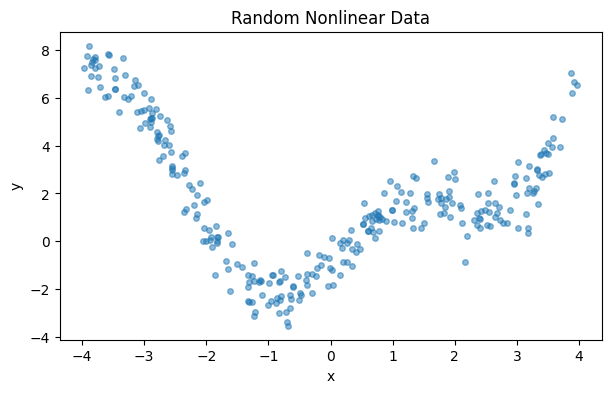

In [10]:
plt.figure(figsize=(7, 4))
plt.scatter(x_nl, y_nl, s=16, alpha=0.5)
plt.title("Random Nonlinear Data")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [11]:
model_nl = torch.nn.Linear(1, 1)
optimizer_nl = torch.optim.SGD(model_nl.parameters(), lr=0.03) # YOUR CODE IN _

epochs_nl = 400
losses_nl = []

for epoch in range(epochs_nl):
    y_pred_nl = model_nl(x_nl)
    loss_nl = mse_loss(y_pred_nl, y_nl) # YOUR CODE IN _

    optimizer_nl.zero_grad()
    loss_nl.backward()
    optimizer_nl.step()

    losses_nl.append(loss_nl.item())

    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch + 1:>3}/{epochs_nl} | MSE: {loss_nl.item():.4f}")

print(f"Final linear-model MSE on nonlinear data: {losses_nl[-1]:.4f}")

Epoch 100/400 | MSE: 7.2920
Epoch 200/400 | MSE: 7.2919
Epoch 300/400 | MSE: 7.2919
Epoch 400/400 | MSE: 7.2919
Final linear-model MSE on nonlinear data: 7.2919


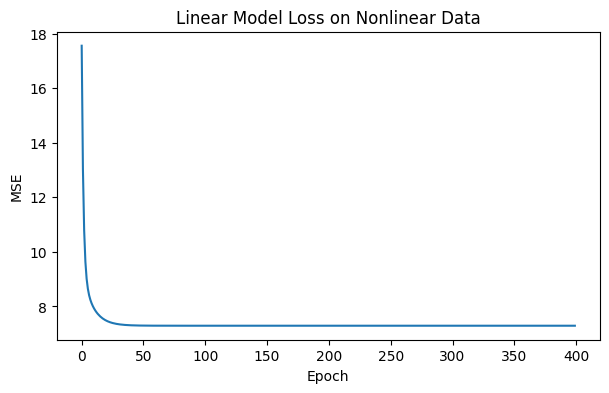

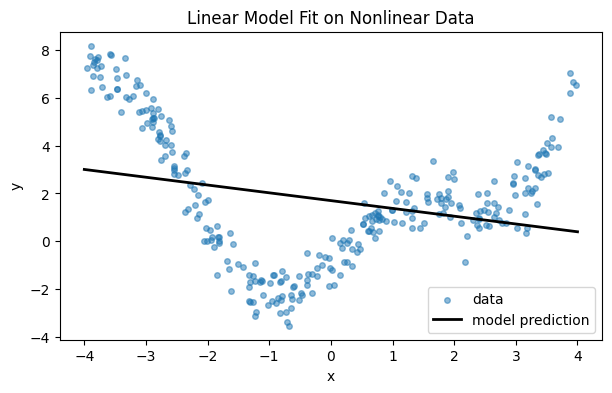

In [12]:
with torch.no_grad():
    x_nl_line = torch.linspace(-4, 4, 300).reshape(-1, 1)
    y_nl_line = model_nl(x_nl_line)

plot_loss(losses_nl, title="Linear Model Loss on Nonlinear Data", ylabel="MSE")
plot_fit(x_nl, y_nl, x_nl_line, y_nl_line, title="Linear Model Fit on Nonlinear Data")

---

## Part 4: ReLU Model on Nonlinear Data

Add one hidden layer with ReLU and compare the fit.


In [13]:
hidden_units = 16

# Build a small ReLU model
#Create a model with a linear input layer, ReLU activation, and linear output layer
relu_model = torch.nn.Sequential(
    torch.nn.Linear(1, hidden_units), # YOUR CODE IN _
    torch.nn.ReLU(), # YOUR CODE IN _
    torch.nn.Linear(hidden_units, 1), # YOUR CODE IN _
)
optimizer_relu = torch.optim.AdamW(relu_model.parameters(), lr=0.01)

epochs_relu = 400
losses_relu = []

for epoch in range(epochs_relu):
    y_pred_relu = relu_model(x_nl)
    loss_relu = mse_loss(y_pred_relu, y_nl) # YOUR CODE IN _

    optimizer_relu.zero_grad()
    loss_relu.backward()
    optimizer_relu.step()

    losses_relu.append(loss_relu.item())

    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch + 1:>4}/{epochs_relu} | ReLU MSE: {loss_relu.item():.4f}")

Epoch  100/400 | ReLU MSE: 1.4741
Epoch  200/400 | ReLU MSE: 0.8849
Epoch  300/400 | ReLU MSE: 0.8326
Epoch  400/400 | ReLU MSE: 0.8158


---

## Part 5: Sigmoid for Binary Classification

Train a simple sigmoid classifier and inspect probability outputs.


In [14]:
# Binary classification data
n_samples_cls = 300
x_cls = np.random.uniform(-6, 6, size=(n_samples_cls, 1)).astype(np.float32)
noise_cls = np.random.normal(0, 1.0, size=(n_samples_cls, 1)).astype(np.float32)
logit_true = 1.6 * x_cls - 0.4 + noise_cls
y_cls = (logit_true > 0).astype(np.float32)

x_cls = torch.tensor(x_cls)
y_cls = torch.tensor(y_cls)

print(f"Classification data shape: {x_cls.shape}")

Classification data shape: torch.Size([300, 1])


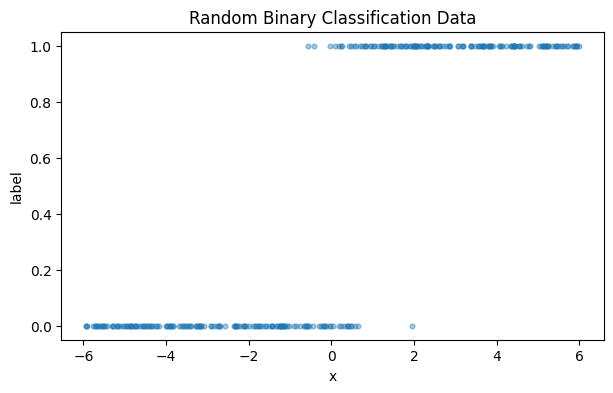

In [15]:
plt.figure(figsize=(7, 4))
plt.scatter(x_cls, y_cls, s=12, alpha=0.4)
plt.title("Random Binary Classification Data")
plt.xlabel("x")
plt.ylabel("label")
plt.show()

In [16]:
# Add a sigmoid activation as output layer to get probabilities in (0, 1)
classifier = torch.nn.Sequential(
    torch.nn.Linear(1, 1),
    # YOUR CODE IN HERE,
    torch.nn.Sigmoid(),

)

# Use PyTorch built-in BCE loss
bce_loss = torch.nn.BCELoss() # YOUR CODE IN _
optimizer_cls = torch.optim.Adam(classifier.parameters(), lr=0.05)

epochs_cls = 400
losses_cls = []

for epoch in range(epochs_cls):
    y_prob = classifier(x_cls)
    loss_cls = bce_loss(y_prob, y_cls)

    optimizer_cls.zero_grad()
    loss_cls.backward()
    optimizer_cls.step()

    losses_cls.append(loss_cls.item())

    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch + 1:>3}/{epochs_cls} | BCE: {loss_cls.item():.4f}")

with torch.no_grad():
    train_prob = classifier(x_cls)
    train_pred = (train_prob >= 0.5).float()
    train_acc = (train_pred == y_cls).float().mean().item()

print(f"Training accuracy: {train_acc:.3f}")
print(f"Probability range: min={train_prob.min().item():.4f}, max={train_prob.max().item():.4f}")

Epoch 100/400 | BCE: 0.1407
Epoch 200/400 | BCE: 0.1190
Epoch 300/400 | BCE: 0.1107
Epoch 400/400 | BCE: 0.1068
Training accuracy: 0.950
Probability range: min=0.0000, max=1.0000


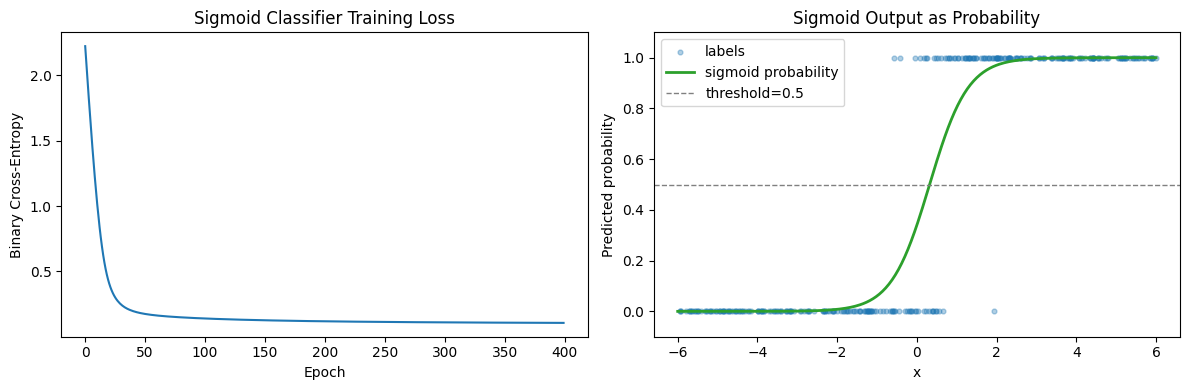

In [17]:
with torch.no_grad():
    x_cls_line = torch.linspace(-6, 6, 300).reshape(-1, 1)
    y_prob_line = classifier(x_cls_line)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(losses_cls)
plt.title("Sigmoid Classifier Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy")

plt.subplot(1, 2, 2)
plt.scatter(x_cls, y_cls, s=12, alpha=0.35, label="labels")
plt.plot(x_cls_line, y_prob_line, color="tab:green", linewidth=2, label="sigmoid probability")
plt.axhline(0.5, color="gray", linestyle="--", linewidth=1, label="threshold=0.5")
plt.ylim(-0.1, 1.1)
plt.title("Sigmoid Output as Probability")
plt.xlabel("x")
plt.ylabel("Predicted probability")
plt.legend()

plt.tight_layout()
plt.show()

---

## Part 6: Optional - `BCEWithLogitsLoss` vs `Sigmoid + BCELoss`

`BCEWithLogitsLoss` combines sigmoid + BCE in one function.

This quick example shows they produce the same loss.


In [ ]:
# No training here: reuse the sigmoid classifier from Part 5
# classifier[0] is the Linear layer (raw scores BEFORE sigmoid)
# classifier is the full Sequential with sigmoid (probabilities AFTER sigmoid)

linear_layer = classifier[0]
logits = linear_layer(x_cls)           # raw scores BEFORE sigmoid
probabilities = classifier(x_cls)       # probabilities AFTER sigmoid

labels = y_cls

# Method 1: Sigmoid + BCELoss
loss_bce = torch.nn.BCELoss()(_, _) # YOUR CODE IN _

# Method 2: BCEWithLogitsLoss (recommended in practice)
# This combines sigmoid + BCE in one numerically stable operation
loss_logits = torch.nn.BCEWithLogitsLoss()(_, _) # YOUR CODE IN _

print(f"BCELoss(sigmoid(logits), labels): {loss_bce.item():.6f}")
print(f"BCEWithLogitsLoss(logits, labels): {loss_logits.item():.6f}")